### 第22章 人脸识别
#### 22.1 级联分类器
1. 基本原理：在开始阶段仅进行非常简单的判断，排除明显不符合要求的实例。被排除的负类不再参与后续分类，提高后面分类的速度
2. Harr 级联分类器：Haar 特征将像素矩形区域划分为白黑两部分，计算该区域的平均灰度差值作为特征。


- 函数 `objects = cv2.CascadeClassifier.detectMultiScale(image[, scaleFactor[, minNeighbors[, flags[, minSize[, maxSize]]]]])` 用来检测人脸
    - `image` 待检测的图像，通常为灰度图
    - `scaleFactor` 表示在前后两次相继的扫描中，搜索窗口的缩放比例，默认为1.1
    - `minNeighbors` 表示构成检测窗口的相邻矩形框的最小个数，默认为3，表示有3个以上的检测标记存在时，才认为人脸存在
    - `flags` 该标志位通常省略
    - `minSize` 表示目标的最小尺寸，小于该尺寸的目标将被忽略
    - `maxSize` 表示目标的最大尺寸，大于该尺寸的目标将被忽略
    - 返回值 `objects` 为一个数组，包含每个检测到的人脸所对应的矩形（x, y, w, h）信息

发现5个人脸!
其位置分别是：
[[290  14  74  74]
 [ 35  77  62  62]
 [127  58  65  65]
 [565  64  64  64]
 [443  62  71  71]]


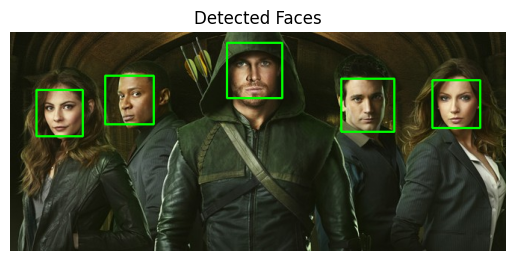

In [ ]:
import cv2
import matplotlib.pyplot as plt

# =============== 1 原始图像处理 ====================
image = cv2.imread("image/dface3.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# ================ 2 加载分类器 ========================
faceCascade = cv2.CascadeClassifier("data/haarcascades/haarcascade_frontalface_default.xml")
# ================= 3 人脸检测========================
faces = faceCascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(5, 5))
# =============== 4 打印输出=====================
print("发现{0}个人脸!".format(len(faces)))
print("其位置分别是：")
print(faces)
# ==================5 标注人脸及显示=======================
for x, y, w, h in faces:
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.title("Detected Faces")
plt.show()

#### 22.2 人脸识别基础
- `None = cv2.face_FaceRecongizer.train(src, labels)` 用给定的数据和相关标签训练生成的实例模型
    - `src` 用来学习的人脸训练图像，必须是灰度图
    - `labels` 人脸图像所对应的标签
- `Label, confidence = cv2.face_FaceRecongizer.predict(src)` 对一个待测人脸图像进行判断
    - `src` 需要识别的人脸图像，必须是灰度图
    - `labels` 返回预测的识别结果标签
    - `confidence` 返回的置信度评分，用来衡量识别结果与原有模型之间的距离
        - LBPH 人脸识别算法的置信度评分范围是0~100，小于50表示识别成功
        - EigenFishfaces / Fishfaces 算法的置信度评分范围是0~20000，小于5000就认为得到了可靠的识别结果

##### 1. LPBH 人脸识别
- 局部二值模式直方图 (Local Binary Patterns Histograms, LBPH) 所使用的模型基于局部二值模式 (Local Binary Patterns, LBP) 算法
- 原理是，将像素点A与其邻近的8个像素点比较，若A大于周围像素点则取1，否则为0；然后将这8个二进制数拼接并转换为十进制数，即为A点的LBP值
- 为了得到不同尺度下的纹理结构，还可以使用圆形邻域。圆形邻域可以用(P, R)来表示，其中P是邻域内参与运算的像素点的数量，R是半径
- 在LBPH算法中，通常先通过LBP算法从图像中提取特征，得到LBP特征图像，再将该图像划分为指定大小的子块后，计算每个子块的直方图；最后得到LBPH特征值。在OpenCV中，通常将LBP特征图划分为8行8列共64个单元。
- `retval = cv2.face.LBPHFaceRecongnizer_create([, radius[, neighbours[, grid_x[, grid_y[, threshold]]]]])` 生成LBPH识别器实例模型
    - `radius` 半径值，默认为 1
    - `neighbors` 邻域点的个数，默认采用8个邻域点
    - `grid_x`, `grid_y` 将LBP特征图像划分为一个个单元cell时，在水平 / 垂直方向上的单元个数，默认值均为8
    - `threshold` 预测所用的阈值，若大于该阈值，则认为没有识别到目标对象

对应的标签label= 0
置信度confidence= 67.68567049817025


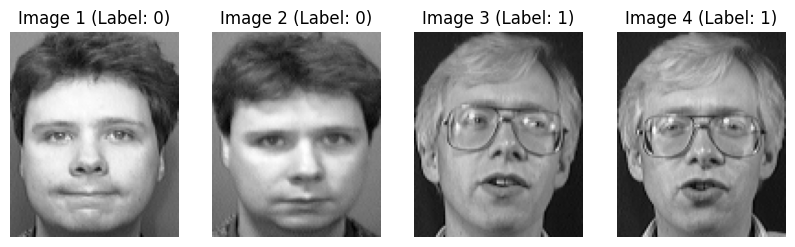

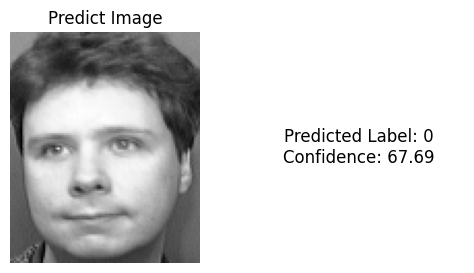

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取训练图像
images = []
images.append(cv2.imread("image/a1.png",cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/a2.png", cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/b1.png", cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/b2.png", cv2.IMREAD_GRAYSCALE))
# 给训练图像贴标签
labels=[0, 0, 1, 1]
# 读取待识别图像
predict_image = cv2.imread("image/a3.png", cv2.IMREAD_GRAYSCALE)
# 识别
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))  
label, confidence = recognizer.predict(predict_image) 
# 打印识别结果
print("对应的标签label =",label)
print("置信度confidence =",confidence)
fig, axes = plt.subplots(1, 4, figsize=(10, 5))
axes[0].imshow(images[0], cmap='gray')
axes[0].set_title('Image 1 (Label: 0)')
axes[0].axis('off')
axes[1].imshow(images[1], cmap='gray')
axes[1].set_title('Image 2 (Label: 0)')
axes[1].axis("off")
axes[2].imshow(images[2], cmap='gray')       
axes[2].set_title('Image 3 (Label: 1)')
axes[2].axis("off")
axes[3].imshow(images[3], cmap='gray')
axes[3].set_title('Image 4 (Label: 1)')
axes[3].axis("off")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(predict_image, cmap='gray')
axes[0].set_title('Predict Image')
axes[0].axis("off")
axes[1].text(0.5, 0.5, f'Predicted Label: {label}\nConfidence: {confidence:.2f}', 
                fontsize=12, ha='center', va='center')
axes[1].axis("off")
plt.show()

##### 2. EigenFaces 人脸识别
- EigenFaces 通常也被称为特征脸，它使用主成分分析 (Principal Component Analysis, PCA) 将高维的人脸数据处理为低维数据后，再进行数据分析处理，获取识别结果
- `retval = cv2.face.EigenFaceRecongnizer_create([, num_components[, threshold]])` 生成 EigneFace 特征量识别器实例模型
    - `num_components` 是在 PCA 过程中保留的特征维度，默认值为0，表示使用所有特征，一般来说，不需要超过80
    - `threshold` 进行人脸识别所采用的阈值

识别标签label= 0
置信度confidence= 1600.5481032349046


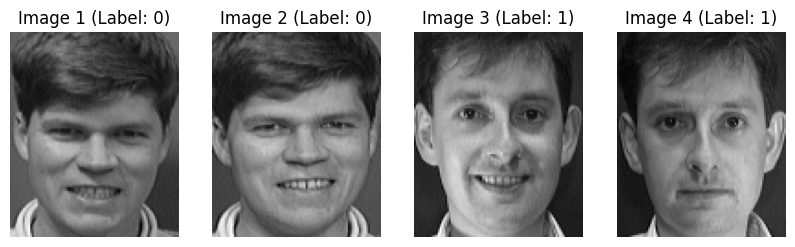

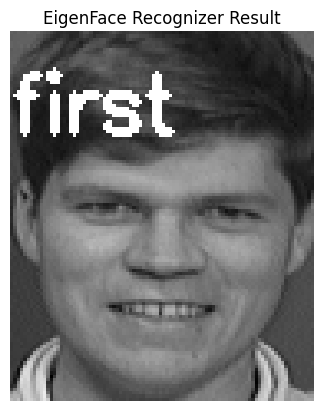

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取训练图像
images = []
images.append(cv2.imread("image/e01.png", cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/e02.png", cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/e11.png", cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/e12.png", cv2.IMREAD_GRAYSCALE))
# 给训练图像贴标签
labels = [0, 0, 1, 1]
# 读取待识别图像
predict_image = cv2.imread("image/eTest.png", cv2.IMREAD_GRAYSCALE)
# 识别
recognizer = cv2.face.EigenFaceRecognizer_create()
recognizer.train(images, np.array(labels))
label, confidence = recognizer.predict(predict_image)
# 打印识别结果
print("识别标签label =", label)
print("置信度confidence =", confidence)
# 可视化输出
fig, axes = plt.subplots(1, 4, figsize=(10, 5))
axes[0].imshow(images[0], cmap="gray")
axes[0].set_title("Image 1 (Label: 0)")
axes[0].axis("off")
axes[1].imshow(images[1], cmap="gray")
axes[1].set_title("Image 2 (Label: 0)")
axes[1].axis("off")
axes[2].imshow(images[2], cmap="gray")
axes[2].set_title("Image 3 (Label: 1)")
axes[2].axis("off")
axes[3].imshow(images[3], cmap="gray")
axes[3].set_title("Image 4 (Label: 1)")
axes[3].axis("off")

name = ["first", "second"]
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(predict_image, name[label], (0, 30), font, 0.8, (255, 255, 255), 2) # 绘制文字
plt.figure()
plt.imshow(predict_image, cmap="gray")
plt.axis("off")
plt.title("EigenFace Recognizer Result")
plt.show()

##### 3. Fisherfaces 人脸识别
- Fisherfaces 采用线性判别分析 (Linear Discriminant Analysis，LDA ) 方法，对特征降维的同时考虑类别信息
- 其思路是：在低维表示下，相同的类应该紧密地聚集在一起；不同的类别应该尽可能地分散开，并且它们之间的距离尽可能地远
- 做线性判别分析时，首先将训练样本集投影到一条直线A上，让投影后的点满足：
    - 同类间的点尽可能地靠近
    - 异类间的点尽可能地远离
- 做完投影后，将待测样本投影到直线A上，根据投影点的位置判定样本的类别，完成识别过程
- `retval = cv2.face.FisherFaceRecongnizer_create([, num_components[, threshold]])` 生成 Fisherfaces 识别器实例模型
    - `num_components` 是在 Fisherfaces 过程中保留的特征维度，默认值为0，让函数自动设置合适的成分数量
    - `threshold` 进行识别所采用的阈值。如果最近的距离超过这个阈值，则函数返回 -1 

识别标签label = 0
置信度confidence = 92.56476232987279


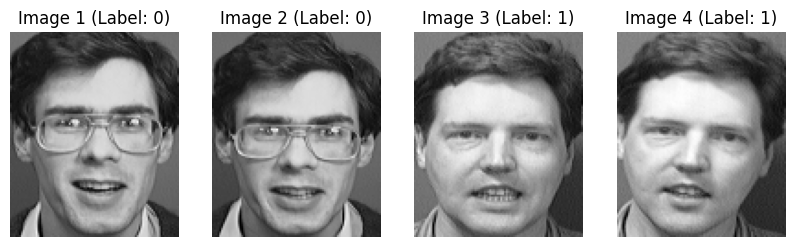

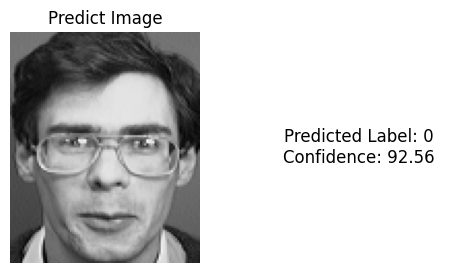

In [16]:
import cv2
import numpy as np

# 读取训练图像
images = []
images.append(cv2.imread("image/f01.png", cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/f02.png", cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/f11.png", cv2.IMREAD_GRAYSCALE))
images.append(cv2.imread("image/f12.png", cv2.IMREAD_GRAYSCALE))
# 给训练图像贴标签
labels = [0, 0, 1, 1]
# 读取待识别图像
predict_image = cv2.imread("image/fTest.png", cv2.IMREAD_GRAYSCALE)
# 识别
recognizer = cv2.face.FisherFaceRecognizer_create()
recognizer.train(images, np.array(labels))
label, confidence = recognizer.predict(predict_image)
# 打印识别结果
print("识别标签label =", label)
print("置信度confidence =", confidence)

fig, axes = plt.subplots(1, 4, figsize=(10, 5))
axes[0].imshow(images[0], cmap="gray")
axes[0].set_title("Image 1 (Label: 0)")
axes[0].axis("off")
axes[1].imshow(images[1], cmap="gray")
axes[1].set_title("Image 2 (Label: 0)")
axes[1].axis("off")
axes[2].imshow(images[2], cmap="gray")
axes[2].set_title("Image 3 (Label: 1)")
axes[2].axis("off")
axes[3].imshow(images[3], cmap="gray")
axes[3].set_title("Image 4 (Label: 1)")
axes[3].axis("off")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(predict_image, cmap="gray")
axes[0].set_title("Predict Image")
axes[0].axis("off")
axes[1].text(
    0.5,
    0.5,
    f"Predicted Label: {label}\nConfidence: {confidence:.2f}",
    fontsize=12,
    ha="center",
    va="center",
)
axes[1].axis("off")
plt.show()

#### 22.3 人脸数据库
- CAS-PEAL(Chinese Academic of Science-Pose, Expression, Accessory, and Lighting) 是中科院计算技术研究所完成的包含1040位志愿者的共99 594幅人脸图像数据库
- AT&T Facedatabase (The ORL Database of Faces)包含40个人，每人10幅共400幅图像。格式为PGM，大小为92x112，灰度级为256
- Yale Facedatabase A 也被称为耶鲁人脸数据库(Yalefaces)，包含15个人，每人11幅灰度图像
- Extend Yale Facedatabase B 扩展的耶鲁人脸数据库，包含28个人，共16128幅图像
- color FERET(Facial Recongnition Technology) Database 包含1564组，共计14126幅图像，由1199个不同的被拍摄对象及365组重复拍摄对象的图像组成